# Feature Engineering

## 1. Apply appropriate transformations (normalization, standardization, log-scaling)

In [32]:
import pandas as pd
df = pd.read_csv('data/train_cleaned.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_null,has_cabin,title_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,0,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,0,1,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0,0,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,0,1,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0,0,Mr


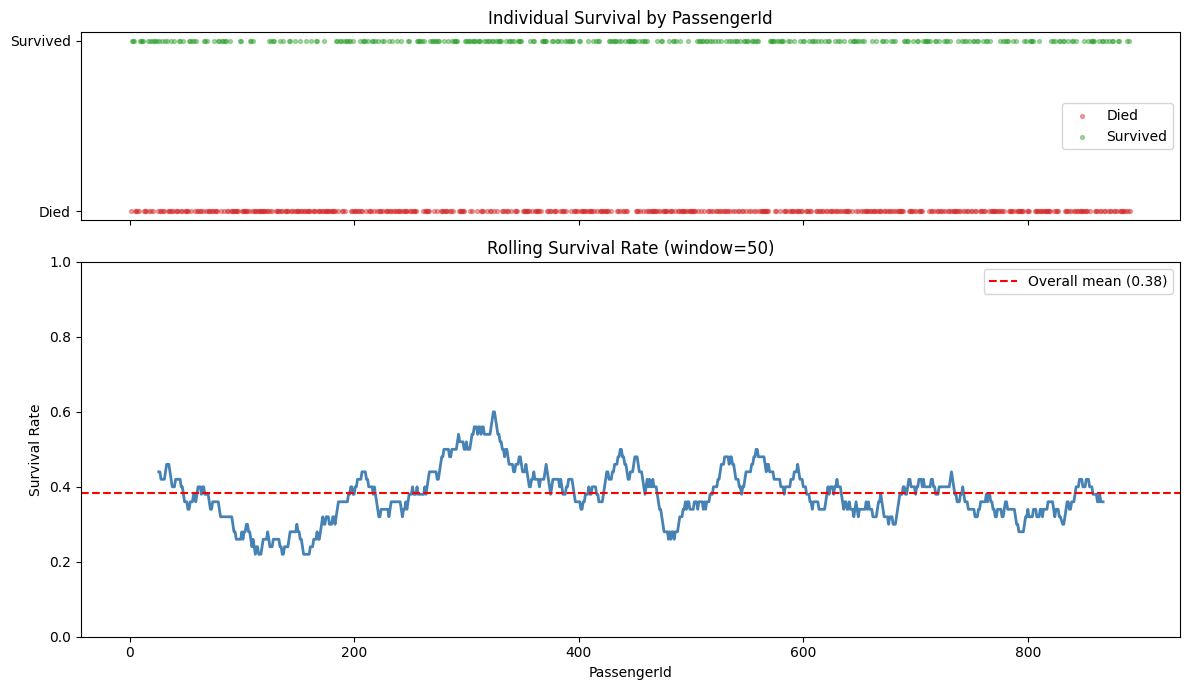

Correlation(PassengerId, Survived): -0.0050


In [33]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [1, 2]})

# Top: strip plot — survived vs died by PassengerId
died = df[df['Survived'] == 0]
surv = df[df['Survived'] == 1]
axes[0].scatter(died['PassengerId'], [0]*len(died), c='#d62728', alpha=0.4, s=8, label='Died')
axes[0].scatter(surv['PassengerId'], [1]*len(surv), c='#2ca02c', alpha=0.4, s=8, label='Survived')
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Died', 'Survived'])
axes[0].set_title('Individual Survival by PassengerId')
axes[0].legend(loc='center right')

# Bottom: rolling survival rate (window=50) to reveal any local trends
window = 50
sorted_df = df.sort_values('PassengerId')
sorted_df['surv_rolling'] = sorted_df['Survived'].rolling(window, center=True).mean()

axes[1].plot(sorted_df['PassengerId'], sorted_df['surv_rolling'], color='steelblue', linewidth=2)
axes[1].axhline(y=df['Survived'].mean(), color='r', linestyle='--', label=f'Overall mean ({df["Survived"].mean():.2f})')
axes[1].set_xlabel('PassengerId')
axes[1].set_ylabel('Survival Rate')
axes[1].set_title(f'Rolling Survival Rate (window={window})')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"Correlation(PassengerId, Survived): {df['PassengerId'].corr(df['Survived']):.4f}")

PassengerId - no change needed. Likely won't be used at all


Survive - binary - no change needed – ohe? - binary should suffice


Pclass - Ordinal - since significance in maginute of class ordering.


Name -> Title - OHE


Sex - categorical? -> normalization?


Age - Normalization


SibSp + Parch = Family size



Ticket - could possibly deduce family groups by same ticket #, create new column for family ID, size of family, etc.


Fare – Likely influenced by Embark (length of trip), but also cabin, as well as PClass
	- normalization should suffice, but check box plot in case. Maybe Log Norm if Right skewed



Cabin - similar to Tikcet-> family grouping. Could indicate same boarding group (friends) rather than solely family


Embarked - OHE




### To be Engineered

1. Family Size (SibSp/Parch)

	- Family Size = SibSp + Parch

	- isAlone: True when FamilySize = 0
	
		- Necessary since marginal impact going from 0->1 likely very different than going from 1->2, 2->3, etc.

In [34]:
# Family Size
df['family_size'] = df['SibSp'] + df['Parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

print("── family_size ──")
print(df['family_size'].value_counts().sort_index())
print(f"\nis_alone: {df['is_alone'].mean():.1%} of passengers")

print("\n── Correlation with Survived ──")
for col in ['family_size', 'is_alone']:
    print(f"{col}: {df[col].corr(df['Survived']):.3f}")

── family_size ──
family_size
1     535
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

is_alone: 60.2% of passengers

── Correlation with Survived ──
family_size: 0.018
is_alone: -0.206


is_alone seems to have predictive power.

Raw family_size does not (near-zero linear correlation), but the survival rate plot below reveals a non-linear U-shape — will bucket instead.

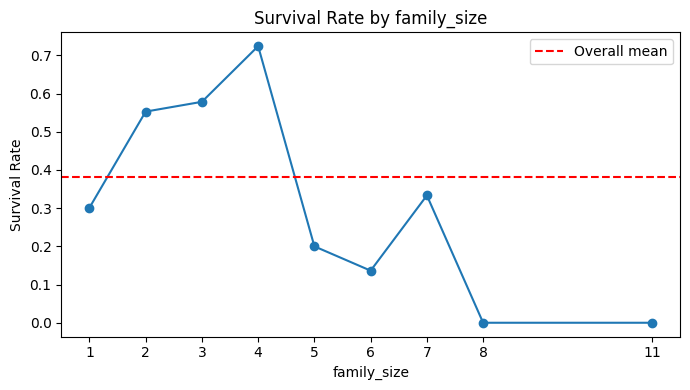

In [35]:
import matplotlib.pyplot as plt

survival = df.groupby('family_size')['Survived'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(survival.index, survival.values, marker='o')
ax.set_xlabel('family_size')
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by family_size')
ax.set_xticks(survival.index)
ax.axhline(y=df['Survived'].mean(), color='r', linestyle='--', label='Overall mean')
ax.legend()

plt.tight_layout()
plt.show()

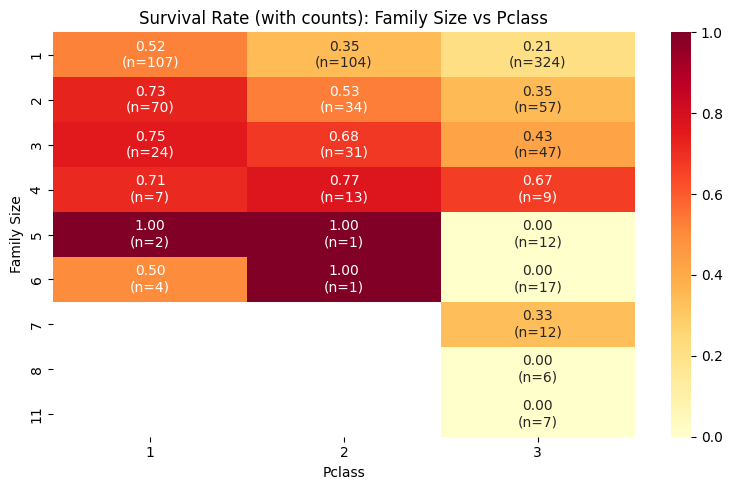

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_rate = df.pivot_table(index='family_size', columns='Pclass', values='Survived', aggfunc='mean')
pivot_count = df.pivot_table(index='family_size', columns='Pclass', values='Survived', aggfunc='count').fillna(0).astype(int)

annot = pivot_rate.copy().astype(str)
for r in pivot_rate.index:
    for c in pivot_rate.columns:
        rate = pivot_rate.loc[r, c]
        count = pivot_count.loc[r, c] if r in pivot_count.index and c in pivot_count.columns else 0
        annot.loc[r, c] = f'{rate:.2f}\n(n={count})' if not pd.isna(rate) else f'n={count}'

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_rate, annot=annot, fmt='', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Survival Rate (with counts): Family Size vs Pclass')
ax.set_ylabel('Family Size')
ax.set_xlabel('Pclass')
plt.tight_layout()
plt.show()

I dove into the data a bit more to see if Pclass was explaining what we saw in the family size vs. survival rate dropoff. However, it's unclear.

Instead, will simply opt for changing family size -> isLargeFamily, as that will capture both family size in [2,4] and >5 through OHE.

In [37]:
# Bin family_size into alone / medium / large, then OHE
df['family_size_bin'] = pd.cut(df['family_size'], bins=[0, 1, 4, 11], labels=['alone', 'medium', 'large'])
df = pd.get_dummies(df, columns=['family_size_bin'], prefix='fam_size', drop_first=True, dtype=int)

# Drop raw components now captured by the bins
df = df.drop(columns=['SibSp', 'Parch', 'family_size', 'is_alone'])

print("── New family columns ──")
print([c for c in df.columns if c.startswith('fam_size')])
print(f"\n── Remaining columns ({len(df.columns)}) ──")
print(df.columns.tolist())

── New family columns ──
['fam_size_medium', 'fam_size_large']

── Remaining columns (16) ──
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'Age_null', 'has_cabin', 'title_group', 'fam_size_medium', 'fam_size_large']


### To Be Encoded

1. Embarked - OHE
	
	- Assume no order relationship

2. Sex – Label Encode

2. PClass – Ordinal

	- Order of classes encodes signal

In [38]:
# Embarked — OHE
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked', drop_first=True, dtype=int)

# Sex — label encode (binary)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# title_group — OHE
df = pd.get_dummies(df, columns=['title_group'], prefix='Title', drop_first=True, dtype=int)

# Pclass — already ordinal (1, 2, 3), leave as-is

print("── Embarked columns ──")
print([c for c in df.columns if c.startswith('Embarked')])
print("\n── Title columns ──")
print([c for c in df.columns if c.startswith('Title_')])
print(f"\nSex unique: {df['Sex'].unique()}")
print(f"Pclass unique: {df['Pclass'].unique()}")
df.head()

── Embarked columns ──
['Embarked_Q', 'Embarked_S']

── Title columns ──
['Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']

Sex unique: [0 1]
Pclass unique: [3 1 2]


,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Title,Age_null,has_cabin,fam_size_medium,fam_size_large,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,A/5 21171,7.2500,NaN,Mr,0,0,1,0,0,1,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,PC 17599,71.2833,C85,Mrs,0,1,1,0,0,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,STON/O2. 3101282,7.9250,NaN,Miss,0,0,0,0,0,1,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,113803,53.1000,C123,Mrs,0,1,1,0,0,1,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,373450,8.0500,NaN,Mr,0,0,0,0,0,1,0,1,0,0


### To be Transformed

1. Fare - Log Transform
	- I assumed there'd be a right skew for this

2. Age - Normalize

Lets check the fare data to see my assumption is correct

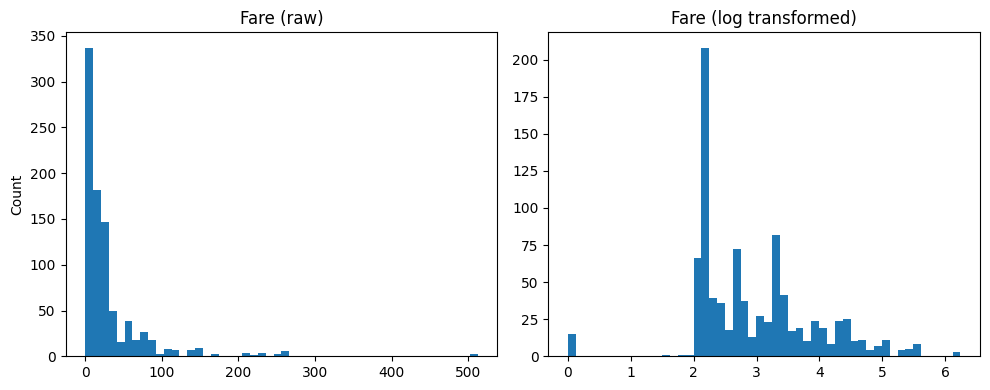

Raw — skew: 4.801
Log — skew: 0.400

── Age (normalized to [0, 1]) ──
count    889.000000
mean       0.366703
std        0.169863
min        0.000000
25%        0.262500
50%        0.368246
75%        0.450000
max        1.000000
Name: Age, dtype: float64


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Reload raw values for idempotent comparison
raw = pd.read_csv('data/train_cleaned.csv')[['Fare', 'Age']]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(raw['Fare'], bins=50)
axes[0].set_title('Fare (raw)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(raw['Fare']), bins=50)
axes[1].set_title('Fare (log transformed)')

plt.tight_layout()
plt.show()

print(f"Raw — skew: {raw['Fare'].skew():.3f}")
print(f"Log — skew: {np.log1p(raw['Fare']).skew():.3f}")

# Apply transforms
df['Fare'] = np.log1p(raw['Fare'])
df['Age'] = (raw['Age'] - raw['Age'].min()) / (raw['Age'].max() - raw['Age'].min())

print(f"\n── Age (normalized to [0, 1]) ──")
print(df['Age'].describe())

We can see a clear right skew on the fare data. Log Transform is warranted for Fare.

### To Be Dropped

1. Passenger ID 

2. Name

3. Cabin (now have hasCabin Flag)

4. Ticket

In [40]:
df = df.drop(columns=['PassengerId', 'Name', 'Cabin', 'Ticket', 'Title'])
print(f"Remaining columns ({len(df.columns)}):")
print(df.columns.tolist())
df.head()

Remaining columns (15):
['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Age_null', 'has_cabin', 'fam_size_medium', 'fam_size_large', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


,Survived,Pclass,Sex,Age,Fare,Age_null,has_cabin,fam_size_medium,fam_size_large,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,0.2750,2.110213,0,0,1,0,0,1,0,1,0,0
1,1,1,1,0.4750,4.280593,0,1,1,0,0,0,0,0,1,0
2,1,3,1,0.3250,2.188856,0,0,0,0,0,1,1,0,0,0
3,1,1,1,0.4375,3.990834,0,1,1,0,0,1,0,0,1,0
4,0,3,0,0.4375,2.202765,0,0,0,0,0,1,0,1,0,0


In [41]:
df.to_csv('data/train_cleaned_and_engineered.csv', index=False)
print(f"Saved {len(df)} rows, {len(df.columns)} columns to data/train_cleaned_and_engineered.csv")
print(f"Columns: {list(df.columns)}")

Saved 889 rows, 15 columns to data/train_cleaned_and_engineered.csv
Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Age_null', 'has_cabin', 'fam_size_medium', 'fam_size_large', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']
